# Lab 1 · The panel

**What you'll build:** three functions that pull the project's three most
load-bearing facts out of the data by hand.

Before any machine learning, you need to be able to say exactly what a *row* is,
what a *feature* is, and what the *target* is. Get those wrong and everything
downstream is confidently wrong.

There is no model in this notebook. That is deliberate.

In [5]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from labgrader import panel, grade_lab, TARGET, CLIMATE

df = panel()
print(df.shape, "rows x columns")
print("target column:", TARGET)

(612, 65) rows x columns
target column: tvwsi


## 1. What is a row?

612 rows. That is **153 polygons × 4 summers** (2022–2025). One row is one
polygon in one summer — a *polygon-summer*.

Watch the word. The City manages **144 GIN corridors**; seven of them are drawn
as several polygons, which is why there are 153. The polygon is the *modelling*
unit, the corridor is the *reporting* unit. Every number in this notebook is
computed on polygons.

In [6]:
print("rows        :", len(df))
print("polygons    :", df["objectid"].nunique())
print("GIN corridors:", df["id"].nunique())
print("summers     :", sorted(df["year"].unique()))

df[["id", "objectid", "year", "ndvi_mean", "swci_mean", "lst_mean", TARGET]].head()

rows        : 612
polygons    : 153
GIN corridors: 144
summers     : [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,id,objectid,year,ndvi_mean,swci_mean,lst_mean,tvwsi
0,36,1,2022,0.841178,0.339456,33.084452,0.001414
1,8,2,2022,0.848286,0.360443,30.358658,0.016599
2,79,3,2022,0.822192,0.335308,34.663307,0.006644
3,81,4,2022,0.620486,0.238868,38.629234,0.016028
4,94,5,2022,0.761471,0.300169,38.332853,0.004082


## 2. Features and the target

**Features** are what the model is allowed to look at. For the main experiment
these are climate-only — no satellite variables, because the target is *derived*
from satellite data and letting satellite features in would be leakage: the
model would predict the target from a rearrangement of itself.

**The target** is `tvwsi`, which the preprint calls **CDEI**. Same column, two
names — worth knowing before someone asks why the code and the paper disagree.

In [7]:
print("climate-only features (%d):" % len(CLIMATE))
for c in CLIMATE:
    print("   ", c)
df[CLIMATE].describe().T[["mean", "std", "min", "max"]].round(3)

climate-only features (14):
    CMD_sm
    CMD_sm_anom
    DD18_sm
    Eref_sm
    Eref_sm_anom
    PPT_sm
    PPT_sm_anom
    Rad_sm
    Tmax_sm
    Tmax_sm_anom
    Tmin_sm
    Tmin_sm_anom
    logPPT_sm
    novelty


,mean,std,min,max
CMD_sm,155.263,67.901,50.000,254.000
CMD_sm_anom,-6.116,67.508,-100.000,91.000
DD18_sm,149.114,34.097,78.000,210.000
Eref_sm,325.859,8.957,306.000,348.000
Eref_sm_anom,9.075,8.087,-5.000,23.000
PPT_sm,173.724,65.018,76.000,301.000
PPT_sm_anom,18.286,64.005,-69.000,131.000
Rad_sm,20.018,0.183,19.600,20.400
Tmax_sm,23.087,0.652,21.700,24.300
Tmax_sm_anom,1.536,0.586,0.500,2.300


## 3. Where the target comes from: the dry edge

Plot every polygon-summer in **NDVI–SWCI space**. NDVI is greenness. SWCI is a
shortwave-infrared water index — how much water the canopy is holding.

The cloud has a **lower boundary**. For any given greenness, there is a driest
the canopy gets. That boundary is the *dry edge*, and it is not a made-up
device — it is the same idea as Moran's trapezoid and Sandholt's TVDI.

CDEI is essentially *how far above that edge you sit*, divided by how hot you're
running compared to your own normal. Near the edge = little water margin for how
green you are = stressed.

published dry edge:  SWCI = -0.1087 + 0.5309 * NDVI


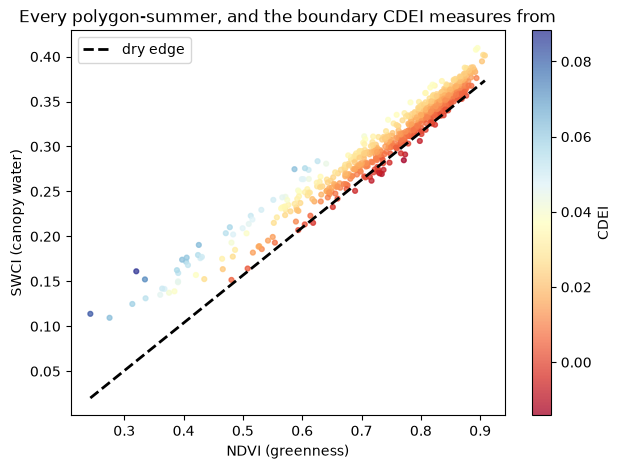

In [8]:
a = df["dry_edge_a"].iloc[0]
b = df["dry_edge_b"].iloc[0]
print(f"published dry edge:  SWCI = {a:.4f} + {b:.4f} * NDVI")

fig, ax = plt.subplots(figsize=(7, 5))
s = ax.scatter(df["ndvi_mean"], df["swci_mean"], c=df[TARGET],
               s=12, cmap="RdYlBu", alpha=.75)
xs = np.linspace(df["ndvi_mean"].min(), df["ndvi_mean"].max(), 50)
ax.plot(xs, a + b * xs, "k--", lw=2, label="dry edge")
ax.set_xlabel("NDVI (greenness)"); ax.set_ylabel("SWCI (canopy water)")
ax.legend(); fig.colorbar(s, ax=ax, label="CDEI")
ax.set_title("Every polygon-summer, and the boundary CDEI measures from")
plt.show()

---
## ✏️ Assignment 1 — `rows_in_year`

Warm-up, so the grader has something to talk to.

Return how many rows belong to a given summer.

In [9]:
def rows_in_year(df, year):
    """Number of rows in `df` whose `year` column equals `year`."""
    return (df['year'] == year).sum()
    raise NotImplementedError

print(rows_in_year(df, 2023))
# rows_in_year(df, 2023) should be 153

153


---
## 4. The fact that decided Phase 3

Here is the single most important measurement in this project, and you are about
to compute it yourself.

Ask, for any column: **does it vary more between places, or between years?**

- Take each corridor's average over the four summers. How spread out are those?
  → that is the **between-corridor** (spatial) variation.
- Take each year's average over all corridors. How spread out are those?
  → that is the **between-year** (temporal) variation.

Divide the first by the second. A ratio **above 1** means the column is mostly a
map. **Below 1** means it is mostly a timeline.

Now the punchline: the *target* varies between places. The climate *predictors*
vary between years. They move along different axes — so a hypothesis about
spatial resolution has nothing to grip.

In [10]:
# Worked example, one column, so you can see the shape of it.
col = "Tmax_sm"
by_corridor = df.groupby("id")[col].mean()
by_year     = df.groupby("year")[col].mean()

print(f"{col}:")
print(f"   sd of the 144 corridor means : {by_corridor.std(ddof=0):.4f}")
print(f"   sd of the 4 year means       : {by_year.std(ddof=0):.4f}")
print(f"   ratio                        : {by_corridor.std(ddof=0)/by_year.std(ddof=0):.3f}")

Tmax_sm:
   sd of the 144 corridor means : 0.2913
   sd of the 4 year means       : 0.5795
   ratio                        : 0.503


### ✏️ Assignment 2 — `spread_ratio`

Return *(between-corridor sd) / (between-year sd)* for any column.

Use `ddof=0` for both, so your number matches the reference exactly.

In [15]:
def spread_ratio(df, col):
    """Between-corridor spread divided by between-year spread.

    > 1  -> the column is mostly a map
    < 1  -> the column is mostly a timeline
    """
    by_corridor = df.groupby("id")[col].mean()
    by_year = df.groupby("year")[col].mean()
    return by_corridor.std(ddof=0) / by_year.std(ddof=0)
    raise NotImplementedError

spread_ratio(df, "Tmax_sm")

np.float64(0.5027479280050032)

In [16]:
# Once it works, run this. Read the table before moving on — it is the whole
# reason Phase 3 came back INCONCLUSIVE.
rows = [{"column": c, "ratio": spread_ratio(df, c)} for c in CLIMATE]
rows.append({"column": "--- TARGET ---", "ratio": np.nan})
rows.append({"column": TARGET, "ratio": spread_ratio(df, TARGET)})
pd.DataFrame(rows).round(3)

,column,ratio
0,CMD_sm,0.112
1,CMD_sm_anom,0.033
2,DD18_sm,0.482
3,Eref_sm,0.491
4,Eref_sm_anom,0.069
5,PPT_sm,0.180
6,PPT_sm_anom,0.028
7,Rad_sm,0.453
8,Tmax_sm,0.503
9,Tmax_sm_anom,0.106


> **Stop and look.** Nearly every climate predictor comes back well *below* 1 —
> ClimateBC over Surrey is a timeline. The target comes back well *above* 1 — the
> stress is a map. That mismatch is not a bug in the code and more corridors
> cannot fix it. It is a property of asking a spatial question over 30 flat
> kilometres.

---
## ✏️ Assignment 3 — `fit_dry_edge`

Now recover the dashed line yourself. The recipe:

1. Cut NDVI into `n_bins` bins **of equal count** (use `np.quantile` on NDVI with
   `np.linspace(0, 1, n_bins+1)` to get the edges — not evenly spaced values).
2. In each bin, take the mean NDVI (call it `x`) and the **5th percentile** of
   SWCI (call it `y`). The 5th percentile, not the minimum: one freak pixel
   aggregate should not define the edge.
3. Skip bins with fewer than `min_per_bin` points.
4. Fit a straight line through the `(x, y)` points with `np.polyfit(x, y, 1)`.

Careful: `np.polyfit` returns **slope first, then intercept**. This function must
return `(intercept, slope)` — the order the pipeline uses.

In [20]:
def fit_dry_edge(ndvi, swci, n_bins=12, q=0.05, min_per_bin=8):
    """Fit the lower boundary of the NDVI-SWCI cloud.

    Returns (intercept, slope) for  SWCI = intercept + slope * NDVI.
    """
    ok = np.isfinite(ndvi) & np.isfinite(swci)
    ndvi, swci = np.asarray(ndvi)[ok], np.asarray(swci)[ok]

    edges = np.quantile(ndvi, np.linspace(0, 1, n_bins + 1))
    
    x = []
    y = []
    
    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (ndvi >= edges[i]) & (ndvi <= edges[i + 1])
        else:
            mask = (ndvi >= edges[i]) & (ndvi < edges[i + 1])
            
        if np.sum(mask) >= min_per_bin:
            x.append(np.mean(ndvi[mask]))
            y.append(np.quantile(swci[mask], q))
            
    slope, intercept = np.polyfit(x, y, 1)
    
    return intercept, slope
    raise NotImplementedError

In [21]:
# Check it against the published edge before you grade.
mine = fit_dry_edge(df["ndvi_mean"].to_numpy(), df["swci_mean"].to_numpy())
print("yours    :", tuple(round(v, 4) for v in mine))
print("published:", (round(a, 4), round(b, 4)))

yours    : (np.float64(-0.1087), np.float64(0.5309))
published: (np.float64(-0.1087), np.float64(0.5309))


---
## Grade it

In [22]:
grade_lab(1, globals())

Lab 1 — The panel
----------------------------------------------------------
  ✓  rows_in_year counts the panel
  ✓  spread_ratio finds the orthogonal axes
  ✓  fit_dry_edge recovers the published edge
----------------------------------------------------------
  3/3 checks passed

  Paste into the Labs tab:   LAB1-3o3-c2edc7cc


'LAB1-3o3-c2edc7cc'

### What you should be able to say out loud

- A row is a **polygon-summer**; 153 polygons carry 144 corridor ids.
- The target is `tvwsi` in code, **CDEI** in the paper.
- CDEI is distance above the dry edge, scaled by relative temperature.
- Surrey's climate predictors vary **more between years than between places**,
  and the target does the opposite. → **Lab 3** shows what that does to a model.